In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

In [ ]:
jupyter_dir = Path.cwd()
fig8_dir = jupyter_dir.parent

data_dir = fig8_dir / 'data'

splitting_file = '/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Calculate_Additional_Columns/final_data/used/FILTERED_DATA_04.csv'
station_file = data_dir / 'stations.txt'
output_path = data_dir / 'station_based_data'
rose_input_path = data_dir / 'rose_generator_rose_input.txt'

In [3]:
splitting_data = pd.read_csv(splitting_file)
stations_df = pd.read_csv(station_file)
stations = stations_df.Name.unique()

In [4]:
if 'Unnamed: 0' in splitting_data.columns:
    splitting_data = splitting_data.drop(columns=['Unnamed: 0'])
splitting_data

,1event,stat,slat,slon,5cuspid,year,doy_det,evla,evlo,10dist(ev-stat),...,40ttime,maxfreq,Elev,anginc_epi,takeoff_ang_epi,path_length_source_to_station_km,traveltime_source_to_station_s,v_avg_source_to_station_kms,SWA_source_to_station,max_ray_depth_km
0,20101016143046800.HOTT.1-8.fb1,HOTT,65.0475,-16.5298,2010-10-16 14:30:46.800,2010,289.6050,65.0194,-16.6574,6.77939,...,-1.287239e+09,7.48782,0.718,42.765269,88.512816,7.574600,2.928349,2.586645,2.987365,2.704215
1,20081130055332180.HOTT.3-8.fb1,HOTT,65.0475,-16.5298,2008-11-30 05:53:32.180,2008,335.2450,65.0149,-16.6680,7.45696,...,-1.228024e+09,5.72034,0.718,43.788490,78.975580,8.200532,3.173602,2.583982,2.441656,2.478399
2,20081218062445360.HOTT.3-8.fb1,HOTT,65.0475,-16.5298,2008-12-18 06:24:45.360,2008,353.2670,65.1457,-16.8005,16.78670,...,-1.229581e+09,6.89921,0.718,36.164064,39.144633,18.909773,6.456348,2.928865,1.974608,3.839185
3,20081201085218180.HOTT.4-10.fb1,HOTT,65.0475,-16.5298,2008-12-01 08:52:18.180,2008,336.3700,65.0131,-16.6108,5.40664,...,-1.228122e+09,7.30519,0.718,43.648513,91.440328,6.160632,2.464305,2.499947,4.360211,2.500000
4,20081021075507360.HOTT.3-8.fb1,HOTT,65.0475,-16.5298,2008-10-21 07:55:07.360,2008,295.3300,65.0220,-16.6744,7.37745,...,-1.224576e+09,7.68394,0.718,44.225260,78.207344,8.103532,3.154277,2.569061,3.882152,2.402384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52851,20160318055342700.DYSA.3-8.fb1,DYSA,64.9349,-16.6755,2016-03-18 05:53:42.700,2016,78.2455,65.0229,-16.6871,9.83104,...,-1.458280e+09,5.95388,0.688,43.336767,65.485368,10.666071,4.028522,2.647639,3.257154,2.573501
52852,20150619085002000.DYSA.3-8.fb1,DYSA,64.9349,-16.6755,2015-06-19 08:50:02.000,2015,170.3680,65.0212,-16.6659,9.62731,...,-1.434704e+09,4.42154,0.688,36.844886,58.272421,11.082981,3.913420,2.832045,4.214388,3.500697
52853,20150827111016260.TOHR.2-6.fb1,TOHR,64.9166,-16.7847,2015-08-27 11:10:16.260,2015,239.4650,65.0149,-16.6744,12.13520,...,-1.440674e+09,3.66982,0.715,44.257816,40.214799,14.242623,5.969348,2.385960,1.005109,2.396813
52854,20140606132124240.TOHR.1-8.fb1,TOHR,64.9166,-16.7847,2014-06-06 13:21:24.240,2014,157.5560,65.0068,-16.6044,13.18350,...,-1.402061e+09,5.26620,0.715,43.419718,39.537841,15.334826,6.284868,2.439960,4.413218,2.554839


In [5]:
# We first create a function that will create a folder for each station and create a {stat}_all.txt file for that station from the amalgamated data

def datafile_creator_single(station, data, output_path):
    """
    station = string, mame of station
    all_data =  pandas.DataFrame object, dataframe containing all data
    output_path = string or Path, path of output required
    
    
    
    
    
    
    """

    output_path = Path(output_path)

    series_rows = []
    for _,row in data.iterrows():
        if row['stat'] == station:
            series_rows.append(row)

    station_df = pd.DataFrame(series_rows)
    
    station_df.to_csv(path_or_buf=(output_path / station / f'{station}_all.txt' ))


In [6]:
def datafile_creator(stations, all_data, output_path):
    """
    stations = list, list of station names 
    all_data =  pandas.DataFrame object, dataframe containing all data
    output_path = string or Path, path of output required
    
    """
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    for station in stations:
        (output_path / station).mkdir(exist_ok=True)

    for i in stations:
        datafile_creator_single(i, all_data, output_path)




In [8]:
datafile_creator(stations = stations, all_data=splitting_data, output_path= output_path)

#We now have all our data in the correct place


In [9]:
#To pass data into GMT we need the data in a particular format to pass into a loop in GMT and plot the roses
#To do this we create a function

#First we take all of our stations

stations_all_df = pd.read_csv(station_file)

#And then we want our used stations

stations_used_df = pd.read_csv(station_file)

stations_used_list = stations_used_df['Name'].to_list()
stations_used_list


['ASK',
 'DALR',
 'DDAL',
 'DREK',
 'DSAN',
 'DYFE',
 'DYSA',
 'EFJA',
 'FLAT',
 'GODA',
 'HOTR',
 'HOTT',
 'HRUR',
 'HRUT',
 'JONS',
 'KATT',
 'KLUR',
 'LOGR',
 'LOKA',
 'LOKAA',
 'LOKAS',
 'LOKT',
 'MOFO',
 'MVET',
 'NAUG',
 'NAUT',
 'NOFL',
 'NOHR',
 'OLAF',
 'OSKV',
 'OSVA',
 'RODG',
 'RODGA',
 'RODGS',
 'SOFA',
 'SOSU',
 'SSUD',
 'STAM',
 'STOR',
 'SVAD',
 'THO',
 'TOHR',
 'VADA',
 'VIBR',
 'VIFE',
 'VIKR']

In [10]:
station_data = pd.read_csv(station_file, index_col=0)

In [11]:
station_data

,Lat,Lon,Elev,Name
0,65.05194,-16.64806,0.955,ASK
1,65.07733,-16.93670,0.801,DALR
2,65.07739,-16.93341,0.801,DDAL
3,65.04944,-16.59703,0.820,DREK
4,64.92149,-16.72847,0.705,DSAN
5,65.10550,-16.92232,0.710,DYFE
6,64.93490,-16.67546,0.688,DYSA
7,65.03358,-16.96212,0.883,EFJA
8,65.18279,-16.49796,0.728,FLAT
9,65.03704,-16.85982,1.266,GODA


In [12]:
# We then want to create our final dataframe to be exported, with the fomat: long, lat, path to data, station


def final_df_creator(dataframe, output_path):

    output_path = Path(output_path)
    station_list = []


    for _,row in dataframe.iterrows():
        station_list.append([
            row['Lon'],
            row['Lat'],
            str(output_path / row['Name'] / f"{row['Name']}_all.txt"),
            row['Name']
        ])


    final_df = pd.DataFrame(station_list)

    return(final_df)





In [13]:
#We can then creat our final dataframe and export it to a csv or txt file
final_df = final_df_creator(station_data, output_path)
final_df.to_csv(rose_input_path, sep=' ', header=False, index=False)
final_df

,0,1,2,3
0,-16.64806,65.05194,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,ASK
1,-16.93670,65.07733,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DALR
2,-16.93341,65.07739,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DDAL
3,-16.59703,65.04944,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DREK
4,-16.72847,64.92149,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DSAN
5,-16.92232,65.10550,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DYFE
6,-16.67546,64.93490,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,DYSA
7,-16.96212,65.03358,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,EFJA
8,-16.49796,65.18279,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,FLAT
9,-16.85982,65.03704,/raid2/jam247/A_Askja_Paper/PAPER_FIGURES/Figu...,GODA


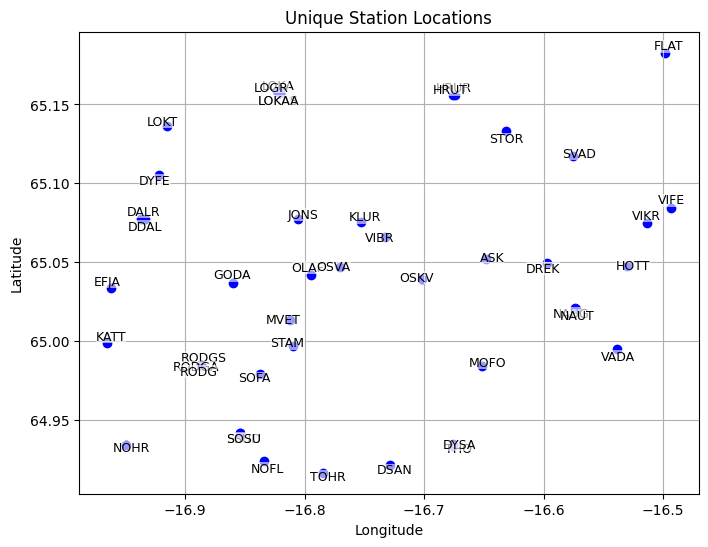

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Drop duplicate (slon, slat, stat) pairs just in case
unique_stations = splitting_data.drop_duplicates(subset=['slon', 'slat', 'stat'])

plt.figure(figsize=(8, 6))
plt.scatter(unique_stations['slon'], unique_stations['slat'], marker='o', color='blue')

# To minimize overlap, stagger label positions using a simple offset pattern
offsets = np.linspace(0, 2 * np.pi, len(unique_stations), endpoint=False)
offset_distance = 0.005  # degrees

for i, (_, row) in enumerate(unique_stations.iterrows()):
    # Offset label directionally from (slon, slat)
    dx = offset_distance * np.cos(offsets[i])
    dy = offset_distance * np.sin(offsets[i])
    plt.text(
        row['slon'] + dx,
        row['slat'] + dy,
        row['stat'],
        fontsize=9,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0)
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Unique Station Locations')
plt.grid(True)
plt.show()

In [18]:
# Find stations closest to HRUT

import numpy as np

# Ensure HRUT is in the dataset
hrut_row = splitting_data[splitting_data['stat'] == 'HRUT']
if hrut_row.empty:
    print("HRUT not found in the data")
else:
    hrut_lat = hrut_row.iloc[0]['slat']
    hrut_lon = hrut_row.iloc[0]['slon']
    
    # Compute distance to all other stations (haversine not needed for small area, use euclidean in degrees)
    def distance(row):
        return np.sqrt((row['slat'] - hrut_lat)**2 + (row['slon'] - hrut_lon)**2)
    
    unique_stations = splitting_data.drop_duplicates(subset=['slon', 'slat', 'stat'])
    unique_stations = unique_stations[unique_stations['stat'] != 'HRUT'].copy()
    unique_stations['distance_deg'] = unique_stations.apply(distance, axis=1)
    
    # Show the 5 closest
    closest = unique_stations.nsmallest(5, 'distance_deg')
    print("Stations closest to HRUT:")
    print(closest[['stat', 'slat', 'slon', 'distance_deg']])

Stations closest to HRUT:
       stat     slat     slon  distance_deg
30636  HRUR  65.1558 -16.6755      0.001100
42139  STOR  65.1331 -16.6314      0.048624
5676   SVAD  65.1175 -16.5750      0.106523
38178  VIBR  65.0662 -16.7326      0.106843
5063    ASK  65.0519 -16.6481      0.107177
